# INTRODUCTION

The following libraries are used to run all of the following code in this report.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Before analyzing the data, it must first be formatted into lists. Below, data concerning US GDP growth rate, quarterly from 2010 Q1 has been put into x and y lists. This data was sourced from the U.S. Bureau of Economic Analysis (BEA), Seasonally Adjusted Annual Rate (SAAR) of Real GDP Growth, in Percent.

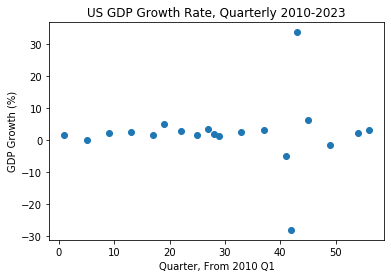

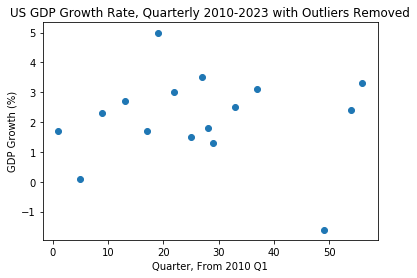

In [2]:
#Entering raw data from table
x = np.array([1 ,5 ,9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56])
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

#Plotting and labelling raw data for demonstration purposes
plt.scatter(x,y)
plt.title('US GDP Growth Rate, Quarterly 2010-2023')
plt.xlabel('Quarter, From 2010 Q1')
plt.ylabel('GDP Growth (%)')
plt.show()


#Creating cleaned data
cleanx = np.concatenate((x[:13],x[17:]))
cleany = np.concatenate((y[:13],y[17:]))

#Plotting and labelling cleaned data for demonstration purposes
plt.scatter(cleanx,cleany)
plt.title('US GDP Growth Rate, Quarterly 2010-2023 with Outliers Removed')
plt.xlabel('Quarter, From 2010 Q1')
plt.ylabel('GDP Growth (%)')
plt.show()

The above dataset shows the seasonally adjusted annual rate (SAAR) of real GDP growth, in percent, from Q1 2010 to Q4 2023. This data is sourced from the U.S. Bureau of Economic Analysis (BEA). Most of the points represent a GDP growth rate of between -1% and 5%. The data also has outlier values which correspond to the shock and boom of the economy due to the COVID-19 pandemic. In the second graph above, these outliers have been removed so that the non-outlying values may be more clearly seen. However, unless otherwise stated, any following analyses will be conducted with the outliers included. The following analysis will consist of three main methods. These include a cubic spline iterpolation, polynomial fit, and least squares regression. All of these algorithms are custom versions produced by myself and do not use any established libraries for regression, fitting, or interpolation.

# PART A: CUBIC SPLINE INTERPOLATION

A cubic spline interpolation consists of n intervals from a dataset with n+1 points. Each interval is a cubic polynomial defined by S_i(x) = a_i + b_i(x - x_i) + c_i(x - x_i)^2 + d_i(x - x_i)^3 . Since there are 20 data points from our original dataset, we must find a, b, c, and d for 19 intervals, representing 76 unknown values. For each interior data point, the spline must pass through the point and have continuous first and second derivatives. For it to be considered a natural spline, we must have second derivatives of zero at the endpoints. From all of those previous conditions, we construct a tridiagonal matrix that will give us our necessary derivatives.

In order to perform this interpolation, we will first construct a tridiagonal matrix.

In [3]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes between data points
    
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        # Subdiagonal
        A[i - 1] = h[i-1]   
        # Main diagonal
        B[i - 1] = 2*(h[i-1]+h[i])  
        # Superdiagonal
        C[i - 1] = h[i]   
        # Right-hand side vector
        D[i - 1] = 6 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])             
    return A, B, C, D

# Set up the tridiagonal matrix for the cubic spline
A, B, C, D = setup_tridiagonal_matrix(x, y)

Now, we will solve it using gaussian elimination, which in this case simplifies into the below Thomas Algorithm.

In [4]:
#Define the Thomas Algorithm
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

# Solve the system and enforce boundary conditions
innerM = thomas_algorithm(A, B, C, D)
M = np.zeros(len(x))
M[1:-1] = innerM

And now we will construct our curve for our cubic spline and plot the results with our original data.

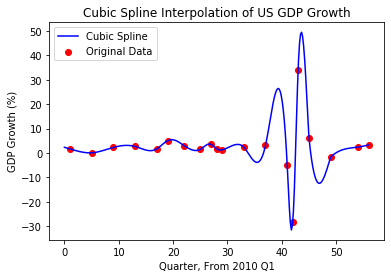

In [5]:
#Algorithm to evaluate the cubic spline's points
def evaluate_spline(x_data, y_data, M, x_query):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
    (M[i] / (6*hi)) * dx_right**3 + # Term 1
    (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
    (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
    (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

#Evaluating the cubic spline's points
xspline = np.linspace(0, np.max(x), 300)
yspline = [evaluate_spline(x, y, M, xi) for xi in xspline]

#Plotting the original data
plt.scatter(x, y, color = 'red', label = 'Original Data')

#Plotting the cubic spline
plt.plot(xspline, yspline, color = 'blue', label = 'Cubic Spline')
plt.title("Cubic Spline Interpolation of US GDP Growth")
plt.xlabel('Quarter, From 2010 Q1')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.show()

Now, let's see what happens when we plot this spline for each quartlerly data point of the total 55. We will do this as both a function and a scatterplot.

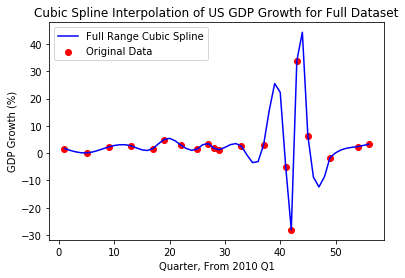

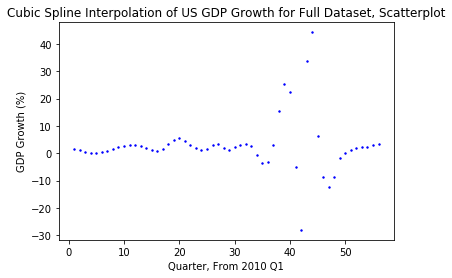

In [6]:
#Construct the full x and y ranges
xfull = np.linspace(1,56,56)
yfull = [evaluate_spline(x, y, M, xi) for xi in xfull]

#Plotting the original data
plt.scatter(x, y, color = 'red', label = 'Original Data')

#Plotting the resulting cubic spline interpolation
plt.plot(xfull, yfull, color = 'blue', label = 'Full Range Cubic Spline')
plt.title("Cubic Spline Interpolation of US GDP Growth for Full Dataset")
plt.xlabel('Quarter, From 2010 Q1')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.show()


#Plotting the resulting cubic spline interpolation as a scatterplot (don't need to plot original, will be included by def.)
plt.scatter (xfull, yfull, color = 'blue', s = 2)
plt.title("Cubic Spline Interpolation of US GDP Growth for Full Dataset, Scatterplot")
plt.xlabel('Quarter, From 2010 Q1')
plt.ylabel('GDP Growth (%)')
plt.show()

The resulting cubic spline from the full quarterly dataset does not make much sense. It is jagged and wildly oscillating, especially near the 2020-2021 values. However, it looks reasonable when observing far away from those data values. The scatterplot (which avoid matplotlib's linear interpolation between calculated points) shows how wildly this interpolation depreciates near the COVID values. It is far from a reasonable plot and no trend/useful information can be discerned. However, for the first 30 quarters or so, a somewhat sensible measured oscillation occurs, mimicking a sin wave.

One of the main features of a cubic spline is that it will pass through every point in the given dataset. Though useful in some applications, this has drawbacks as seen in the prior interpolations. Because the spline had to account for the COVID outliers, namely the values of -28.1 in 2020 Q2, it lost numerical stability. The Runge Phenomenon occurs when accounting for extra data will cause wild oscillations in the resultant interpolation. Because our spline had to account for this extreme value, it oscillates wildly in the interval (though technically the Runge Phenomenon specifically refers to the edges of a polynomial interpolation oscillating wildly). By accounting for the extreme values, we have lost usefulness as a tool for interpolation. If trimming our data wasn't an option, a weighted least squares would likely be more useful to see the actual trend.

# PART B: POLYNOMIAL & LEAST SQUARES COMPARISON

Let's move on to minimizing residuals instead of hitting every single point. We will now fit a degree 4 polynomial using least squares.

First, let's construct a Vandermonde matrix and make sure its condition number is below 10^12.

In [7]:
#Construct the Vandermonde matrix
A = np.column_stack([x**0, x**1, x**2, x**3, x**4])
    
#Check its condition number
print(f"Condition Number: {np.linalg.cond(A):.2e}")

Condition Number: 1.82e+07


This condition number is below the 10^12 benchmark. Thus, we can proceed and solve our matrix to generate our polynomial.

In [8]:
#Set up and solve the normal equations
LHS = A.T @ A
RHS = A.T @ y
polycofs = np.linalg.solve(LHS, RHS)

And now we can plot this degree 4 polynomial against our cubic spline and original data.

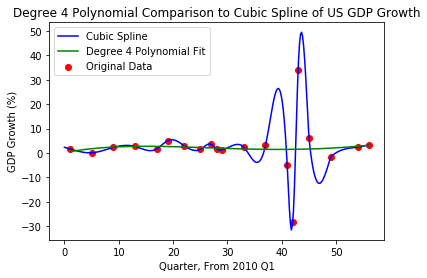

In [9]:
#Construct the polynomial x's and y's
xpoly = np.linspace(1,56,20)
ypoly = polycofs[0] + polycofs[1]*xpoly + polycofs[2]*xpoly**2 + polycofs[3]*xpoly**3 + polycofs[4]*xpoly**4

#Plot the original data
plt.scatter(x, y, color = 'red', label = 'Original Data')

#Plot the cubic spline
plt.plot(xspline, yspline, color = 'blue', label = 'Cubic Spline')

#Plot the degree 4 polynomial
plt.plot(xpoly,ypoly, color = 'green', label = 'Degree 4 Polynomial Fit')
plt.title("Degree 4 Polynomial Comparison to Cubic Spline of US GDP Growth")
plt.xlabel('Quarter, From 2010 Q1')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.show()

We will now make a residual plot for the polynomial fit to better see errors.

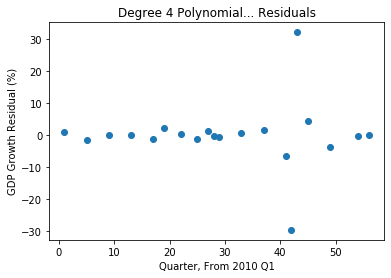

In [10]:
#Plotting the least squares linear model
plt.scatter(x,y-(ypoly))
plt.title("Degree 4 Polynomial... Residuals")
plt.xlabel('Quarter, From 2010 Q1')
plt.ylabel('GDP Growth Residual (%)')
plt.show()

From the above plot, we can see that the cubic spline better fits the data points but does not effectively capure the trend in the data. The degree 4 polynomial seems to ignore the outliers and still manages to capure the slight oscillations of the data. The cubic spline, however, oscillates wildly during the COVID quarters. Thus, there exists a tradeoff. If we want to capure the trend of the data, we are unable to cross every point and vise versa. We must choose between an approximation or interpolation depending on a given dataset. In this case the polynomial more effectively captures the trend.

We will now fit a least squares linear model to the data excluding the COVID outliers.

In [11]:
#Defining the least squares algorithm
def leastsquare(x,y):
    #Calculating the necessary sums for the algorithm
    sum1 = np.sum(x)
    sum2 = np.sum(y)
    sum3 = np.sum(x*x)
    sum4 = np.sum(x*y)
    
    #Using least squares formula to find slope and intercept
    n = len(x)
    m = (n*sum4-sum1*sum2)/(n*sum3-sum1**2)
    c = (sum2-m*sum1)/n
    return(m,c)

#Applying the least squares algorithm to the cleaned data without COVID outliers
m, c = leastsquare(cleanx,cleany)
print(f"The slope of the least squares linear model is {m}.")

The slope of the least squares linear model is -0.001906988188976378.


From our calculations, the slope of the least squares linear model for the cleaned data is approximately -0.0019. This represents a pretty flat, negative slope. Though there is a trend of decreasing US GDP growth rate over time, it is a very slow decrease.

We will now plot the least squares linear model against the cleaned data in order to visualize this effect.

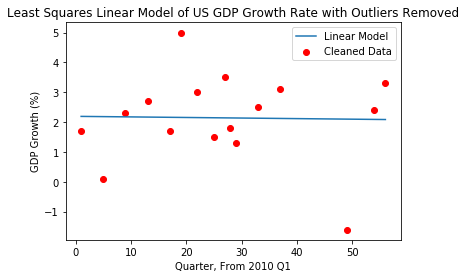

In [12]:
#Plotting the cleaned data points
plt.scatter(cleanx,cleany, color = 'red', label = 'Cleaned Data')

#Plotting the least squares linear model
plt.plot(cleanx,m*cleanx+c, label = 'Linear Model')
plt.title("Least Squares Linear Model of US GDP Growth Rate with Outliers Removed")
plt.xlabel('Quarter, From 2010 Q1')
plt.ylabel('GDP Growth (%)')
plt.legend()
plt.show()

And now we plot the corresponding residual plot in order to better see the fit of our least squares linear model.

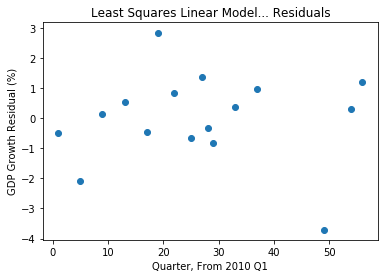

In [13]:
#Plotting the least squares linear model
plt.scatter(cleanx,cleany-(m*cleanx+c))
plt.title("Least Squares Linear Model... Residuals")
plt.xlabel('Quarter, From 2010 Q1')
plt.ylabel('GDP Growth Residual (%)')
plt.show()

A linear trend does not make much economic sense for this data. First, a linear trend assumes that the US GDP growth rate will increase or decrease at a constant rate. This doesn't occur in real life as it fluctuates up and down according to various economic indicators. A linear trend would imply permanent accelerated growth or decay. Second, using a linear least squares model assumes that the error is constant, which is not the case in real life. For example, though we removed the COVID values, they show that these data points can fluctuate wildly from the trend and break any linear model. Third, the linear model will assume that errors are independent which is not the case in real life. A bad quarter can affect the following quarters of GDP growth. Finally, similar to the first point, real life sees periods of growth and periods of recession. A perfectly linear model would smooth over all of that and hallucinate constant growth or decay.

# PART C: METHOD JUSTIFICATION

For a policymaker who wants to estimate the GDP growth of a quarter between two known data points, I would recommend using a cubic spline interpolation. First, it is the more accurate method as compared to a polynomial fit. Since it definitionally will pass every point in the given data set, there is a low error with those values and will thus likely be closer to the true values of interpolated points. Second, though both are relatively smooth, the cubic spline has continuous first and second derivatives at each interior point which are locally determined, making it more effective at guessing values. Though the polynomial would also be smooth and differentiable, each "segment" is created with the whole dataset in mind, not just the local values, creating error. Third, the cubic spline is less sensitive to outliers. Though it has wild oscillations in the COVID quarters, those oscillations are relegated to those quarters, because of the previously mentioned locallity. The polynomial, however, has error plagued throughout because of the COVID outliers. My suggestion would be to use cubic spline for its smoothness, accuracy, and isolated sensitivity to outliers making it the ideal choice to interpolate an interior value.

# PART C ADDENDUM: BIG O NOTATION

Big O notation describes how the runtime or memory usage of an algorithm grows as the size of a dataset increases. It only accounts for the most dominantly scaling term, which has the largest impact with larger sized datasets. This makes it useful for comparing the efficiency and scalability of different algorithms.

Let's review the algorithms we used for each method, starting with the cubic spline. The bottleneck of creating the cubic spline is solving the tridiagonal matrix using the Thomas Algorithm. Because this is a special form of gaussian elimination only needing to linearly parse the matrix, it is O(n) complexity. For a degree 4 polynomial fit, the bottleneck is setting up the vandermonde matrix and solving it, scaling as 5xn, corresponding to O(n) complexity. The bottleneck of the linear least squares model is calculating the np sums which are O(n) according to their library.

In summary, no this will not change any decisions on which algorithm to use. Since they all follow O(n) complexity, there are no huge advantages picking one or the other (in terms of big O notation). Additionally, a dataset like this following quarters in a year which advance very slowly. The detriments of inefficient big O's wouldn't been seen for centuries.

# CONCLUSION

Each of the methods of analysis had their respective strengths. For interpolation, cubic spline was the best, as it locally accounted for exact values and interpolates beautifully if away from outliers. For trend analysis, I would recommend the polynomial fit because it is resistant to the outliers and produces a smooth line through the general shape of the data. But each of the methods also had their respective weaknesses. Cubic spline is practically useless near outliers because it must reach each point. Polynomial fit is globally determined and fails to capture the smaller trends seen in this data due to the relatively low condition number of 1.82e+07. Finally, the linear model is unrealistic for a system as complex as the U.S. economy.